In [5]:
# Data Handling
import pandas as pd
import numpy as np
import math

# Remove truncation of columns and rows in output
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical Analysis
from scipy.stats import zscore

# Machine Learning
from sklearn.linear_model import LinearRegression

In [6]:
# Load the dataset
df_active = pd.read_csv(r'/Users/kevin/Programming/multi-agentic-sales-representative-system/datasets/ebay_active_listings.csv')
print(f"Dataset shape: {df_active.shape}")
df_active.head()

Dataset shape: (6758, 14)


,item_id,title,category,price,currency,condition,condition_id,buying_options,seller_feedback_score,seller_feedback_pct,location_country,location_city,image_url,listing_url
0,v1|277933775534|2560830004120,Waterproof Phone Cover Case Carry Iphone Sams...,smartphones,2.48,GBP,New,1000.0,FIXED_PRICE,27108,98.0,GB,NaN,https://i.ebayimg.com/images/g/gHwAAOSwFBFoT~G...,https://www.ebay.co.uk/itm/277933775534?_skw=i...
1,v1|336555199828|546003356436,Phone Case for Samsung Galaxy Protective Case ...,smartphones,9.92,GBP,New,1000.0,FIXED_PRICE,50446,99.3,DE,NaN,https://i.ebayimg.com/images/g/otwAAOSwHbRn3B7...,https://www.ebay.co.uk/itm/336555199828?_skw=i...
2,v1|358482641720|0,iPhone 4 and Samsung Galaxy J3 Disabled Mobile...,smartphones,42.30,GBP,For parts or not working,7000.0,FIXED_PRICE|BEST_OFFER,14,100.0,GB,NaN,https://i.ebayimg.com/images/g/34IAAeSwKuRp64j...,https://www.ebay.co.uk/itm/358482641720?_skw=i...
3,v1|277924893467|0,Samsung Galaxy A10 Mobile Phone Blue 32GB SM-A...,smartphones,36.00,GBP,Used,3000.0,FIXED_PRICE,1283,99.8,GB,NaN,https://i.ebayimg.com/images/g/qagAAeSw8tFpzDe...,https://www.ebay.co.uk/itm/277924893467?_skw=i...
4,v1|178069829989|0,Universal Tripod Telescopic Mobile Phone Camer...,smartphones,5.99,GBP,New,1000.0,FIXED_PRICE,183,98.4,GB,NaN,https://i.ebayimg.com/images/g/-YYAAeSwi0Vp6Jy...,https://www.ebay.co.uk/itm/178069829989?_skw=i...


In [11]:
# ── Quick EDA snapshot ──
print("=" * 70)
print("DATASET SUMMARY")
print("=" * 70)
print(f"\nShape: {df_active.shape[0]:,} rows × {df_active.shape[1]} columns")
print(f"\nNumeric columns: {df_active.select_dtypes(include=[np.number]).columns.tolist()}")
print(f"\nCategorical columns: {df_active.select_dtypes(include=['object']).columns.tolist()}")
print(f"\nDescriptive statistics:")
df_active.describe().round(2)

DATASET SUMMARY

Shape: 6,758 rows × 14 columns

Numeric columns: ['price', 'condition_id', 'seller_feedback_score', 'seller_feedback_pct', 'location_city']

Categorical columns: ['item_id', 'title', 'category', 'currency', 'condition', 'buying_options', 'location_country', 'image_url', 'listing_url']

Descriptive statistics:


/var/folders/hq/v_7wt_d51sn37zqs9vlsf41c0000gn/T/ipykernel_41707/783780937.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(f"\nCategorical columns: {df_active.select_dtypes(include=['object']).columns.tolist()}")


,price,condition_id,seller_feedback_score,seller_feedback_pct,location_city
count,6758.00,6740.00,6758.00,6758.00,0.0
mean,227.40,1909.41,237731.17,96.44,NaN
std,768.30,1205.79,1393446.93,16.79,NaN
min,0.99,1000.00,0.00,0.00,NaN
25%,14.14,1000.00,410.25,99.20,NaN
50%,29.99,1000.00,2616.00,99.70,NaN
75%,89.00,3000.00,38235.00,100.00,NaN
max,7023.00,7000.00,13752012.00,100.00,NaN


<Axes: xlabel='price'>

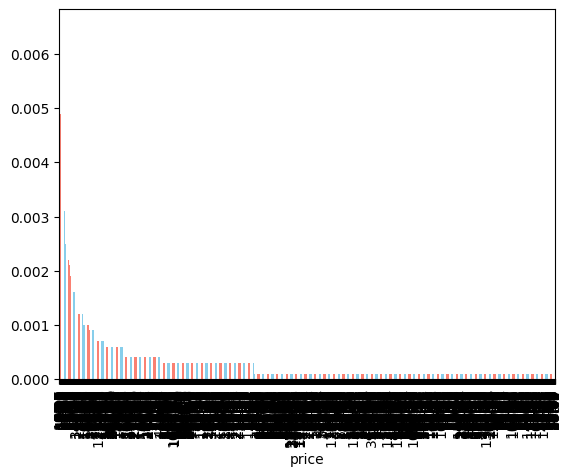

In [8]:
# Print target approval rate. 
df_active['price'].value_counts(normalize=True).round(4).plot(kind='bar', color=['skyblue', 'salmon'])

TARGET VARIABLE: PRICE ANALYSIS

Descriptive Statistics for Price:
count    6758.000000
mean      227.398141
std       768.301115
min         0.990000
25%        14.140000
50%        29.990000
75%        88.997500
max      7023.000000
Name: price, dtype: float64

Missing values in price: 0
Zero prices: 0
Negative prices: 0

Skewness: 5.3622
Kurtosis: 30.9406


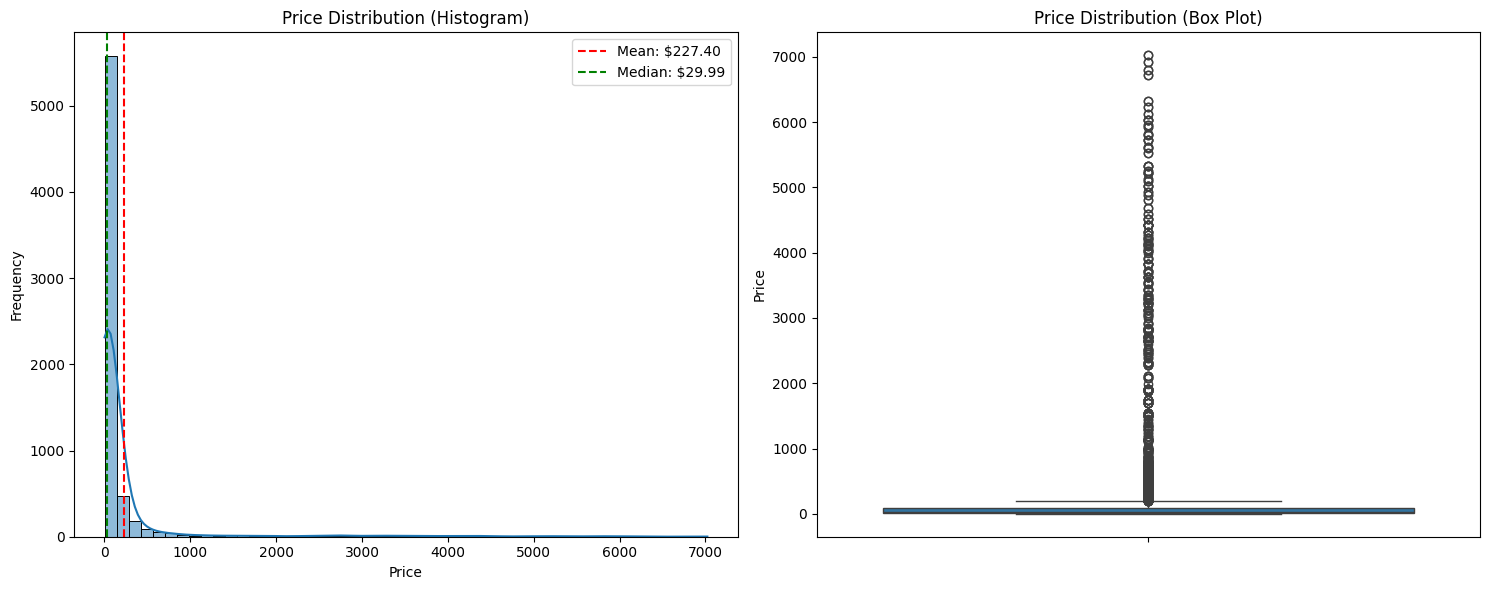


Price Ranges:
Min price: $0.99
Max price: $7023.00
Median price: $29.99
Mean price: $227.40
Q1 (25th percentile): $14.14
Q3 (75th percentile): $89.00
IQR: $74.86

Potential outliers (IQR method): 916 items
Lower bound: $-98.15
Upper bound: $201.28
Outlier price range: $201.34 - $7023.00


In [10]:
# ── Target Variable Analysis: Price ──
print("=" * 70)
print("TARGET VARIABLE: PRICE ANALYSIS")
print("=" * 70)

# Basic descriptive statistics
print(f"\nDescriptive Statistics for Price:")
price_stats = df_active['price'].describe()
print(price_stats)

# Check for missing values
missing_price = df_active['price'].isnull().sum()
print(f"\nMissing values in price: {missing_price}")

# Check for zero or negative prices
zero_price = (df_active['price'] == 0).sum()
negative_price = (df_active['price'] < 0).sum()
print(f"Zero prices: {zero_price}")
print(f"Negative prices: {negative_price}")

# Distribution analysis
print(f"\nSkewness: {df_active['price'].skew():.4f}")
print(f"Kurtosis: {df_active['price'].kurtosis():.4f}")

# Visualize distribution
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Histogram
sns.histplot(df_active['price'], bins=50, ax=axes[0], kde=True)
axes[0].set_title('Price Distribution (Histogram)')
axes[0].set_xlabel('Price')
axes[0].set_ylabel('Frequency')
axes[0].axvline(df_active['price'].mean(), color='red', linestyle='--', label=f'Mean: ${df_active["price"].mean():.2f}')
axes[0].axvline(df_active['price'].median(), color='green', linestyle='--', label=f'Median: ${df_active["price"].median():.2f}')
axes[0].legend()

# Box plot
sns.boxplot(y=df_active['price'], ax=axes[1])
axes[1].set_title('Price Distribution (Box Plot)')
axes[1].set_ylabel('Price')

plt.tight_layout()
plt.show()

# Price ranges analysis
print(f"\nPrice Ranges:")
print(f"Min price: ${df_active['price'].min():.2f}")
print(f"Max price: ${df_active['price'].max():.2f}")
print(f"Median price: ${df_active['price'].median():.2f}")
print(f"Mean price: ${df_active['price'].mean():.2f}")

# Quartiles
q1 = df_active['price'].quantile(0.25)
q3 = df_active['price'].quantile(0.75)
iqr = q3 - q1
print(f"Q1 (25th percentile): ${q1:.2f}")
print(f"Q3 (75th percentile): ${q3:.2f}")
print(f"IQR: ${iqr:.2f}")

# Outliers (using IQR method)
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr
outliers = df_active[(df_active['price'] < lower_bound) | (df_active['price'] > upper_bound)]
print(f"\nPotential outliers (IQR method): {len(outliers)} items")
print(f"Lower bound: ${lower_bound:.2f}")
print(f"Upper bound: ${upper_bound:.2f}")

if len(outliers) > 0:
    print(f"Outlier price range: ${outliers['price'].min():.2f} - ${outliers['price'].max():.2f}")

ADDITIONAL PRICE VISUALIZATIONS

Dataset columns: ['item_id', 'title', 'category', 'price', 'currency', 'condition', 'condition_id', 'buying_options', 'seller_feedback_score', 'seller_feedback_pct', 'location_country', 'location_city', 'image_url', 'listing_url']

Data types:
item_id                      str
title                        str
category                     str
price                    float64
currency                     str
condition                    str
condition_id             float64
buying_options               str
seller_feedback_score      int64
seller_feedback_pct      float64
location_country             str
location_city            float64
image_url                    str
listing_url                  str
dtype: object


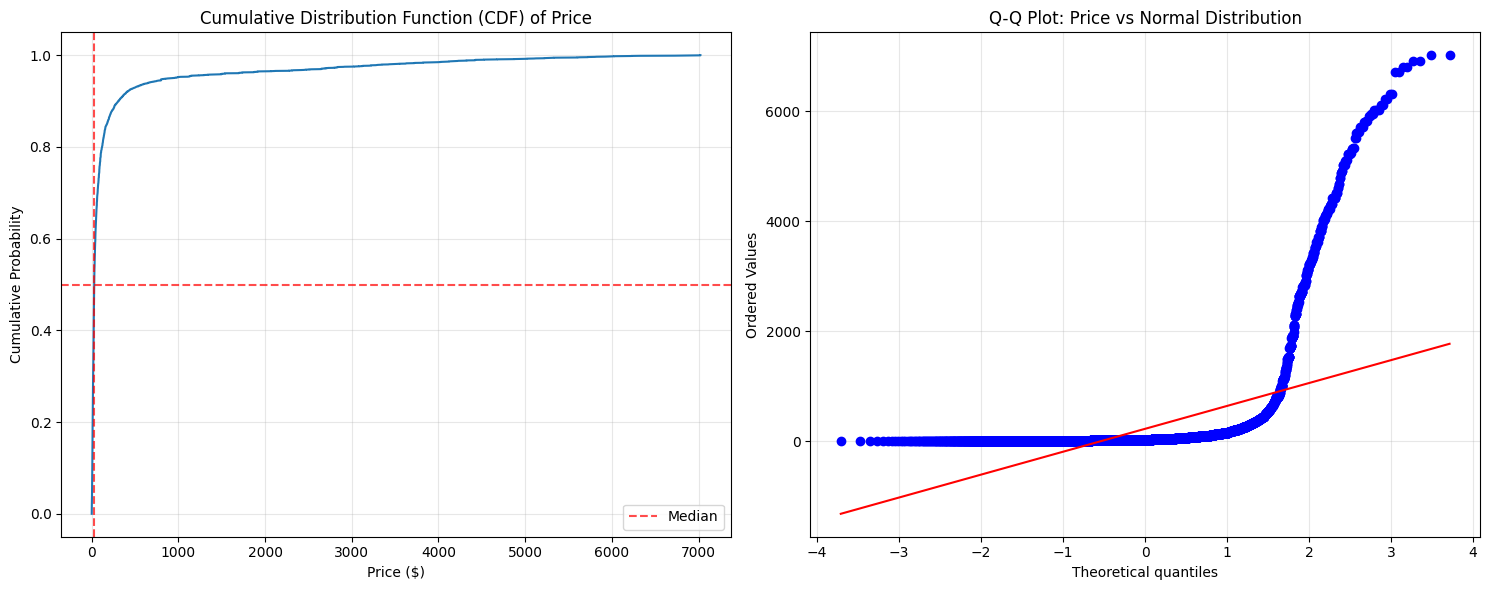

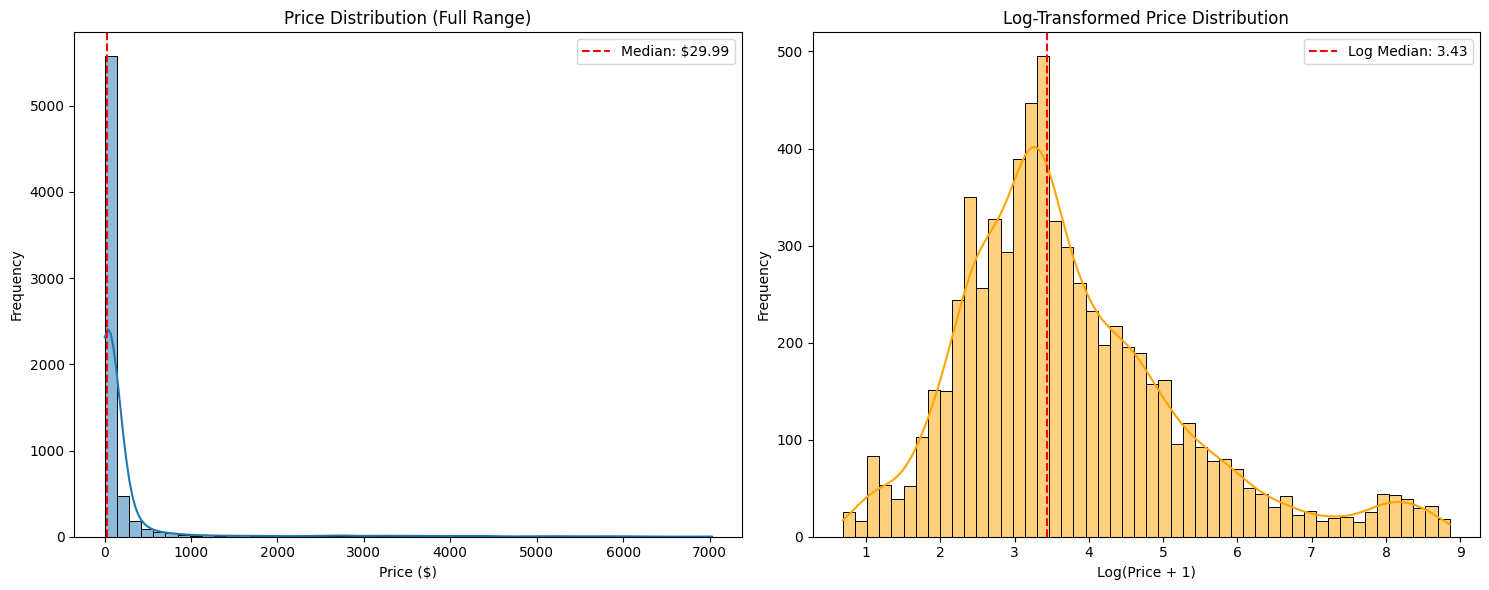

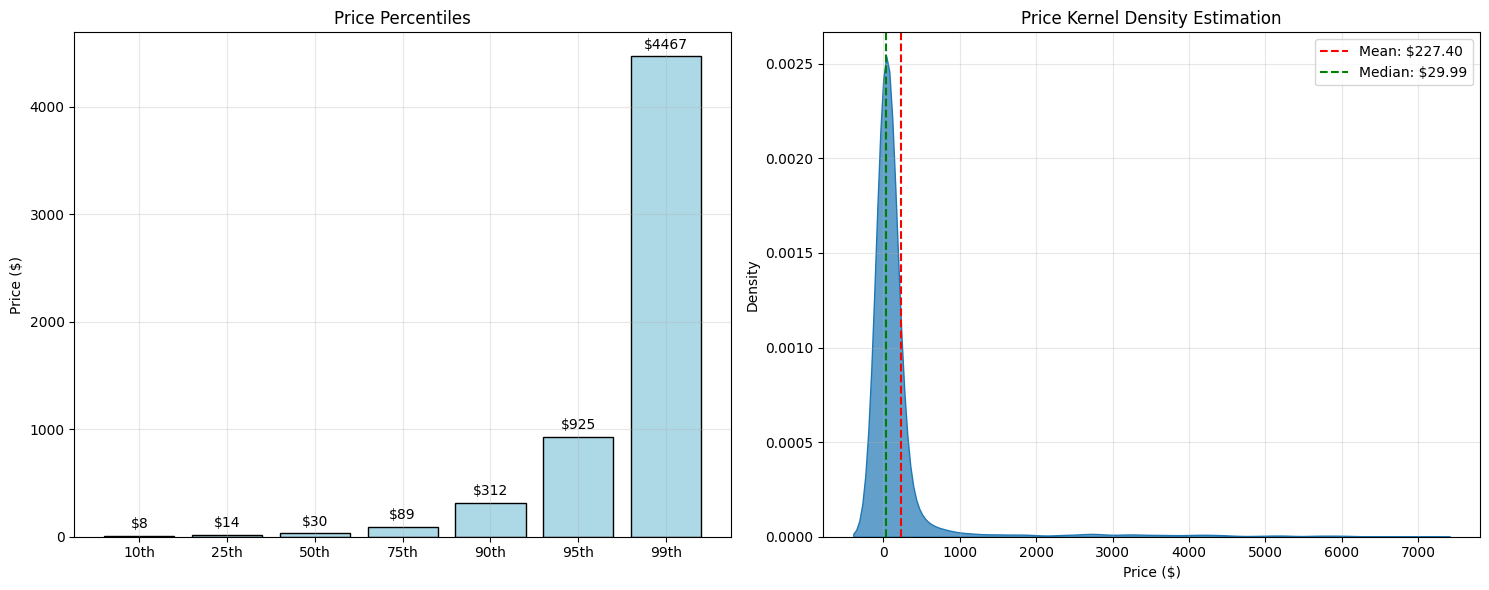


Log-transformed price statistics:
Mean (log): 3.7459
Std (log): 1.5134
Skewness (log): 1.0175
Kurtosis (log): 1.2189


In [12]:
# ── Additional Price Visualizations ──
print("=" * 70)
print("ADDITIONAL PRICE VISUALIZATIONS")
print("=" * 70)

# Check available columns for potential correlations
print(f"\nDataset columns: {df_active.columns.tolist()}")
print(f"\nData types:")
print(df_active.dtypes)

# Visualization 1: Cumulative Distribution Function (CDF)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# CDF
sorted_prices = np.sort(df_active['price'])
yvals = np.arange(len(sorted_prices))/float(len(sorted_prices)-1)
axes[0].plot(sorted_prices, yvals)
axes[0].set_title('Cumulative Distribution Function (CDF) of Price')
axes[0].set_xlabel('Price ($)')
axes[0].set_ylabel('Cumulative Probability')
axes[0].grid(True, alpha=0.3)
axes[0].axhline(0.5, color='red', linestyle='--', alpha=0.7, label='Median')
axes[0].axvline(df_active['price'].median(), color='red', linestyle='--', alpha=0.7)
axes[0].legend()

# Q-Q plot (Quantile-Quantile plot) to check normality
from scipy import stats
stats.probplot(df_active['price'], dist="norm", plot=axes[1])
axes[1].set_title('Q-Q Plot: Price vs Normal Distribution')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Visualization 2: Price distribution with log transformation
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Original price histogram (zoomed)
sns.histplot(df_active['price'], bins=50, ax=axes[0], kde=True)
axes[0].set_title('Price Distribution (Full Range)')
axes[0].set_xlabel('Price ($)')
axes[0].set_ylabel('Frequency')
axes[0].axvline(df_active['price'].median(), color='red', linestyle='--', label=f'Median: ${df_active["price"].median():.2f}')
axes[0].legend()

# Log-transformed price histogram
log_prices = np.log1p(df_active['price'])  # log(1+x) to handle zeros if any
sns.histplot(log_prices, bins=50, ax=axes[1], kde=True, color='orange')
axes[1].set_title('Log-Transformed Price Distribution')
axes[1].set_xlabel('Log(Price + 1)')
axes[1].set_ylabel('Frequency')
axes[1].axvline(np.log1p(df_active['price']).median(), color='red', linestyle='--',
                label=f'Log Median: {np.log1p(df_active["price"]).median():.2f}')
axes[1].legend()

plt.tight_layout()
plt.show()

# Visualization 3: Price percentiles and density
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Price percentiles
percentiles = [10, 25, 50, 75, 90, 95, 99]
percentile_values = np.percentile(df_active['price'], percentiles)
axes[0].bar(range(len(percentiles)), percentile_values, color='lightblue', edgecolor='black')
axes[0].set_xticks(range(len(percentiles)))
axes[0].set_xticklabels([f'{p}th' for p in percentiles])
axes[0].set_title('Price Percentiles')
axes[0].set_ylabel('Price ($)')
axes[0].grid(True, alpha=0.3)

# Add value labels on bars
for i, v in enumerate(percentile_values):
    axes[0].text(i, v + max(percentile_values)*0.01, f'${v:.0f}', ha='center', va='bottom')

# Kernel Density Estimation (KDE) plot
sns.kdeplot(df_active['price'], ax=axes[1], fill=True, alpha=0.7)
axes[1].set_title('Price Kernel Density Estimation')
axes[1].set_xlabel('Price ($)')
axes[1].set_ylabel('Density')
axes[1].grid(True, alpha=0.3)

# Add mean and median lines
axes[1].axvline(df_active['price'].mean(), color='red', linestyle='--', label=f'Mean: ${df_active["price"].mean():.2f}')
axes[1].axvline(df_active['price'].median(), color='green', linestyle='--', label=f'Median: ${df_active["price"].median():.2f}')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"\nLog-transformed price statistics:")
print(f"Mean (log): {log_prices.mean():.4f}")
print(f"Std (log): {log_prices.std():.4f}")
print(f"Skewness (log): {log_prices.skew():.4f}")
print(f"Kurtosis (log): {log_prices.kurtosis():.4f}")

PRICE ANALYSIS BY CATEGORICAL VARIABLES

Price statistics by condition:
                                             mean  median  count
condition                                                       
Acceptable                                  19.98   16.48      4
Brand New                                   24.66   15.14     23
Excellent - Refurbished                    239.14  199.00     43
For parts or not working                    43.06   30.00    105
Gebraucht                                  105.77   65.30     28
Good                                         9.52    8.86      7
Good - Refurbished                         169.77  153.99     48
Graded                                     150.82   57.62     34
Like New                                    13.55    3.00     85
Neu                                         35.78   15.63     48
Neu: Sonstige (siehe Artikelbeschreibung)  371.79  258.93      3
New                                        347.42   24.68   3495
New other (see det

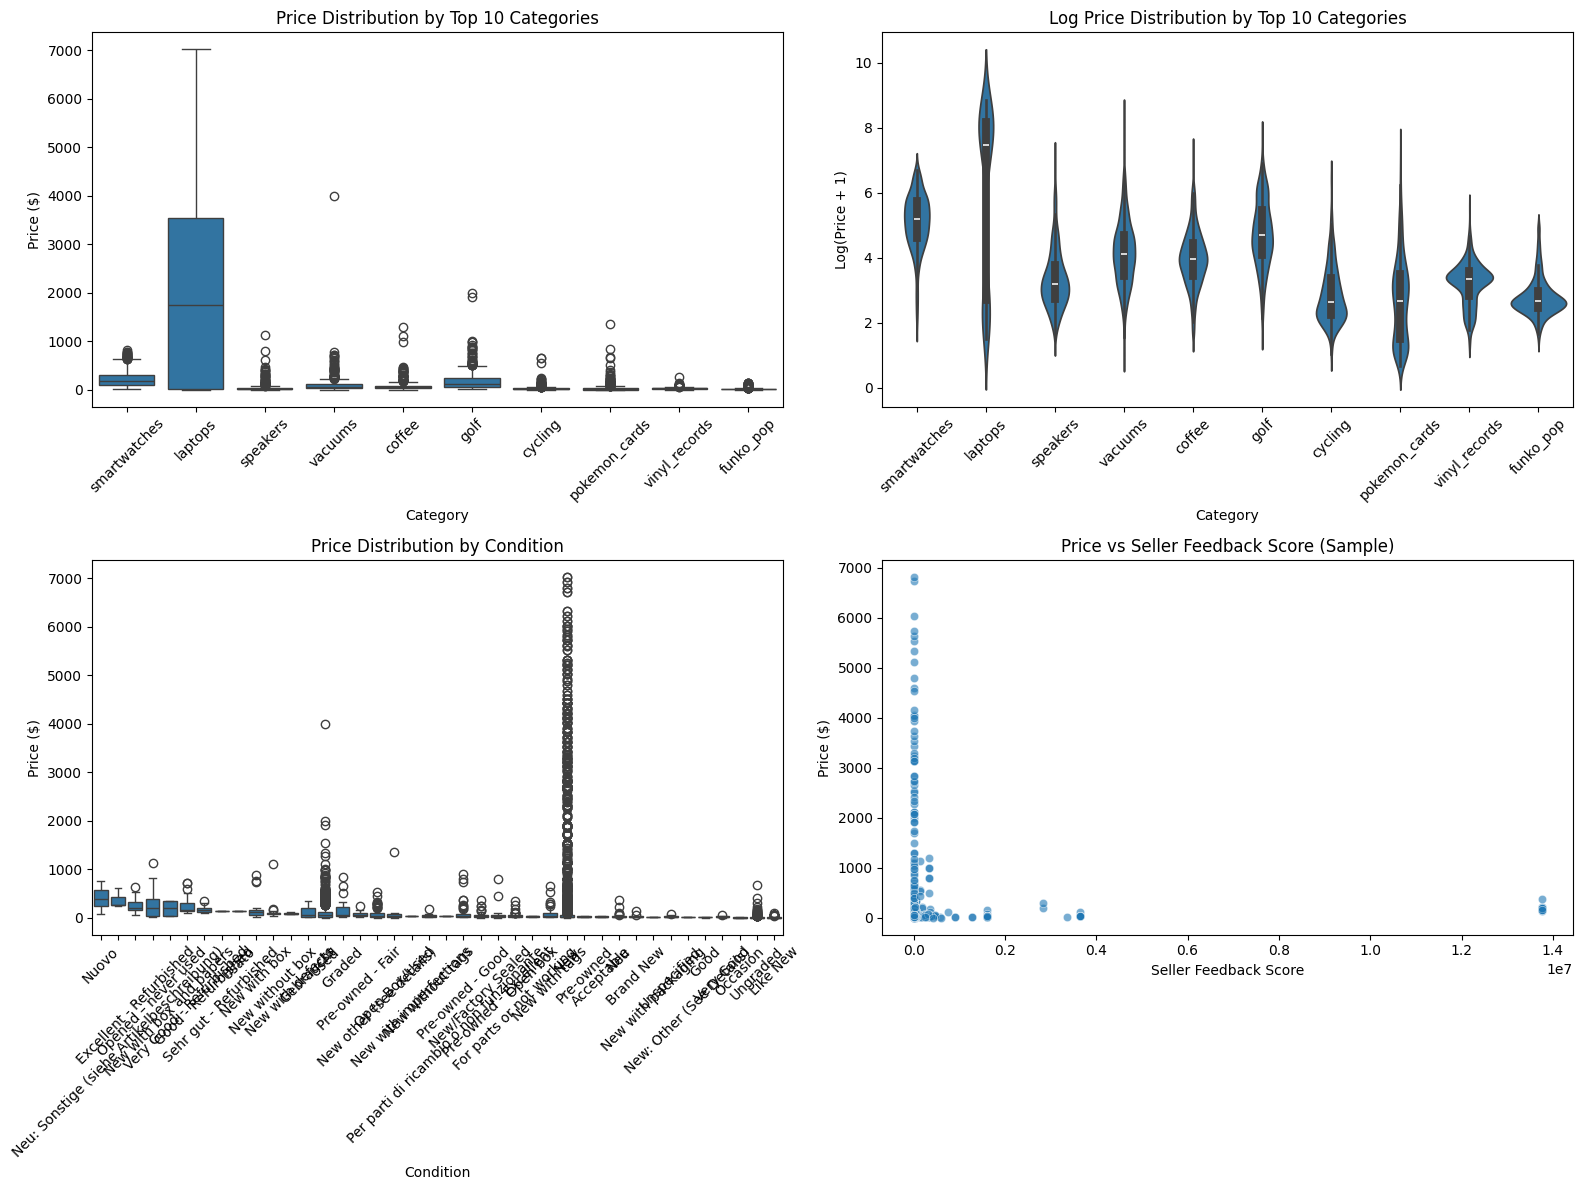


Top 10 categories summary:
               mean_price  median_price  min_price  max_price  count
category                                                            
speakers            48.78         23.43       3.59    1121.74    500
coffee              81.16         51.66       4.11    1284.99    500
cycling             28.46         13.14       1.83     649.00    500
golf               191.04        108.38       4.95    1989.90    500
laptops           2086.17       1743.08       3.50    7023.00    500
vacuums            106.77         59.99       1.95    3994.49    500
pokemon_cards       38.33         13.63       0.99    1364.06    500
smartwatches       221.94        180.00       5.95     821.75    500
vinyl_records       29.31         27.03       2.77     260.00    499
funko_pop           19.09         13.30       3.31     147.77    499


In [13]:
# ── Price Analysis by Categorical Variables ──
print("=" * 70)
print("PRICE ANALYSIS BY CATEGORICAL VARIABLES")
print("=" * 70)

# Visualization 4: Price by Category (Top 10 categories)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Top 10 categories by count
top_categories = df_active['category'].value_counts().head(10).index
df_top_cat = df_active[df_active['category'].isin(top_categories)]

# Box plot by category
sns.boxplot(data=df_top_cat, x='category', y='price', ax=axes[0,0])
axes[0,0].set_title('Price Distribution by Top 10 Categories')
axes[0,0].set_xlabel('Category')
axes[0,0].set_ylabel('Price ($)')
axes[0,0].tick_params(axis='x', rotation=45)

# Violin plot by category (log scale for better visualization)
sns.violinplot(data=df_top_cat, x='category', y=np.log1p(df_active.loc[df_top_cat.index, 'price']), ax=axes[0,1])
axes[0,1].set_title('Log Price Distribution by Top 10 Categories')
axes[0,1].set_xlabel('Category')
axes[0,1].set_ylabel('Log(Price + 1)')
axes[0,1].tick_params(axis='x', rotation=45)

# Price by condition
condition_order = df_active.groupby('condition')['price'].median().sort_values(ascending=False).index
sns.boxplot(data=df_active, x='condition', y='price', order=condition_order, ax=axes[1,0])
axes[1,0].set_title('Price Distribution by Condition')
axes[1,0].set_xlabel('Condition')
axes[1,0].set_ylabel('Price ($)')
axes[1,0].tick_params(axis='x', rotation=45)

# Average price by condition
condition_stats = df_active.groupby('condition')['price'].agg(['mean', 'median', 'count']).round(2)
print(f"\nPrice statistics by condition:")
print(condition_stats)

# Scatter plot: Price vs Seller Feedback Score (sample for visibility)
sample_size = min(1000, len(df_active))
df_sample = df_active.sample(n=sample_size, random_state=42)
sns.scatterplot(data=df_sample, x='seller_feedback_score', y='price', alpha=0.6, ax=axes[1,1])
axes[1,1].set_title('Price vs Seller Feedback Score (Sample)')
axes[1,1].set_xlabel('Seller Feedback Score')
axes[1,1].set_ylabel('Price ($)')

plt.tight_layout()
plt.show()

# Summary statistics by category
print(f"\nTop 10 categories summary:")
category_summary = df_active.groupby('category').agg({
    'price': ['mean', 'median', 'min', 'max', 'count']
}).round(2)
category_summary.columns = ['mean_price', 'median_price', 'min_price', 'max_price', 'count']
category_summary = category_summary.sort_values('count', ascending=False).head(10)
print(category_summary)

COMPREHENSIVE EDA: CORRELATIONS AND FEATURE ANALYSIS

MISSING VALUES ANALYSIS
               Missing Count  Missing Percentage
location_city           6758              100.00
image_url                 19                0.28
condition_id              18                0.27
condition                 11                0.16

NUMERIC VARIABLES CORRELATION ANALYSIS


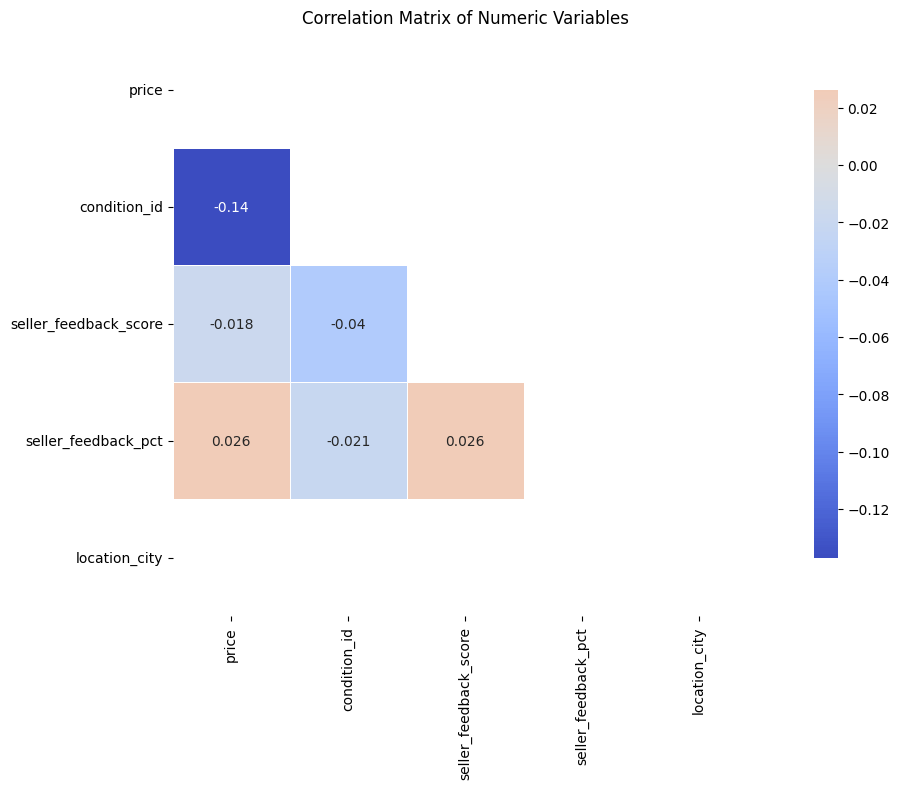


Correlations with Price (target variable):
seller_feedback_pct: 0.0259
seller_feedback_score: -0.0181
condition_id: -0.1370
location_city: nan

CATEGORICAL VARIABLES ANALYSIS

ITEM_ID ANALYSIS:
------------------------------
Unique values: 6758
Top 5 values:
item_id
v1|277933775534|2560830004120    1
v1|336555199828|546003356436     1
v1|358482641720|0                1
v1|277924893467|0                1
v1|178069829989|0                1
Missing values: 0

TITLE ANALYSIS:
------------------------------
Unique values: 6394
Top 5 values:
title
Laptop Sleeve Case NoteBook Pouch Bag for Macbook Air Pro 11" 13" 14" 15".          17
Turtle Beach Recon 50P Wired Gaming Headset PS5-PS4-Xbox-PC-MAC-Nintendo switch      9
Laptop Bag for Xiaomi Lenovo Dell Notebook Computer Laptop Sleeve for Macbook Ai     8
Laptop Sleeve Case Bag for MacBook Air Pro 13 14 15.6 Inch Notebook Cover            7
Laptop Bag For Xiaomi Lenovo Dell Notebook Computer Laptop Sleeve For Macbook Ai     7
Missing values: 

/var/folders/hq/v_7wt_d51sn37zqs9vlsf41c0000gn/T/ipykernel_41707/3439396521.py:45: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df_active.select_dtypes(include=['object']).columns
/var/folders/hq/v_7wt_d51sn37zqs9vlsf41c0000gn/T/ipykernel_41707/3439396521.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_values.values, y=top_values.index, palette='viridis')


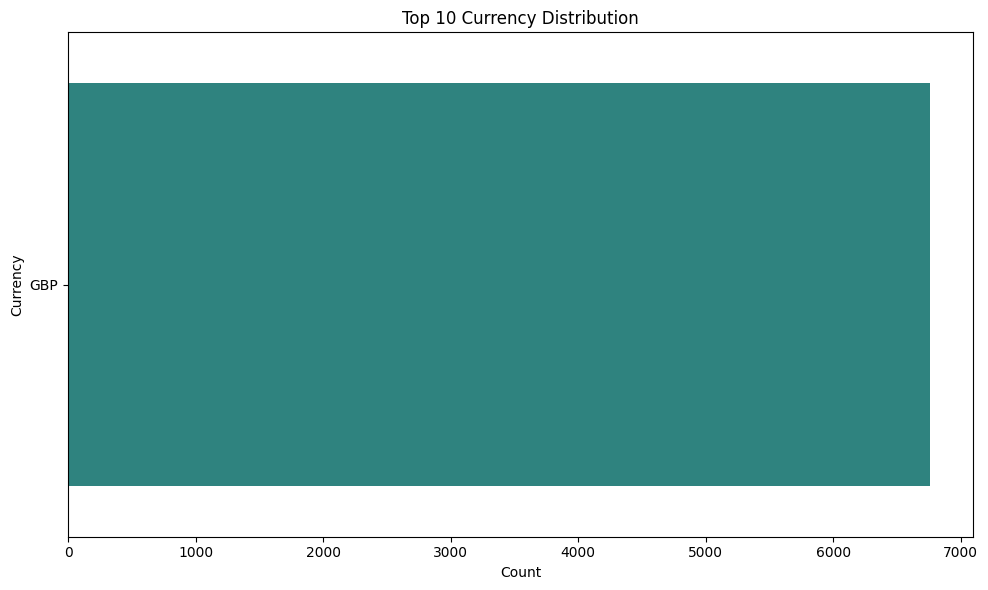


CONDITION ANALYSIS:
------------------------------
Unique values: 40
Top 5 values:
condition
New                        3495
Used                       1746
Ungraded                    285
Pre-owned - Good            184
New other (see details)     126
Missing values: 11

BUYING_OPTIONS ANALYSIS:
------------------------------
Unique values: 3
Top 5 values:
buying_options
FIXED_PRICE               4177
FIXED_PRICE|BEST_OFFER    2524
FIXED_PRICE|AUCTION         57
Missing values: 0


/var/folders/hq/v_7wt_d51sn37zqs9vlsf41c0000gn/T/ipykernel_41707/3439396521.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_values.values, y=top_values.index, palette='viridis')


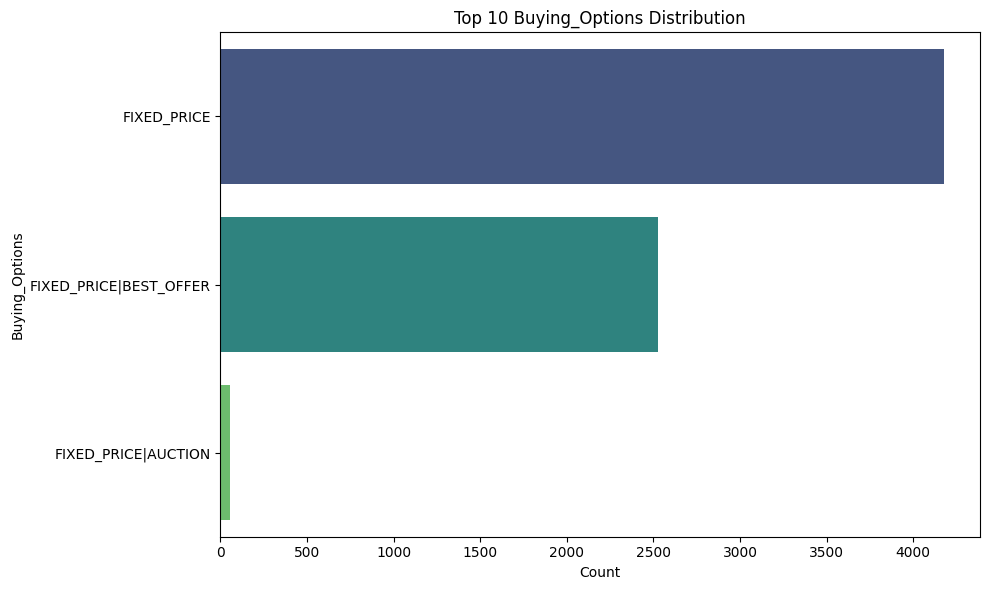


LOCATION_COUNTRY ANALYSIS:
------------------------------
Unique values: 21
Top 5 values:
location_country
GB    4295
US    1422
CN     573
JP     237
DE      77
Missing values: 0

IMAGE_URL ANALYSIS:
------------------------------
Unique values: 6400
Top 5 values:
image_url
https://i.ebayimg.com/images/g/VikAAeSwzORpsx4e/s-l225.jpg    30
https://i.ebayimg.com/images/g/mscAAeSw7mppsx5M/s-l225.jpg    30
https://i.ebayimg.com/images/g/wNMAAeSwrA1psySR/s-l225.jpg    24
https://i.ebayimg.com/images/g/v-8AAeSwNC1psySP/s-l225.jpg    24
https://i.ebayimg.com/images/g/m7cAAeSwiCBpsySL/s-l225.jpg    24
Missing values: 19

LISTING_URL ANALYSIS:
------------------------------
Unique values: 6758
Top 5 values:
listing_url
https://www.ebay.co.uk/itm/277933775534?_skw=iphone+samsung+galaxy+mobile+phone&hash=item40b624daae:g:gHwAAOSwFBFoT~GH    1
https://www.ebay.co.uk/itm/336555199828?_skw=iphone+samsung+galaxy+mobile+phone&hash=item4e5c40cd54:g:otwAAOSwHbRn3B7Q    1
https://www.ebay.co.uk/itm/3584

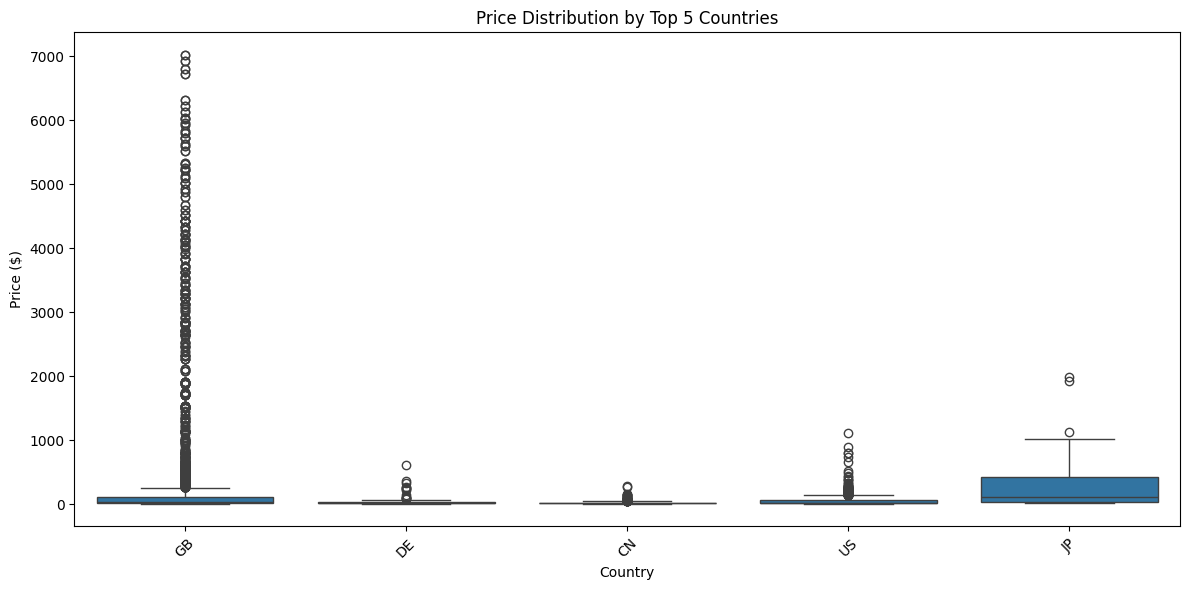


SELLER ANALYSIS
Unique sellers: 1905
Seller feedback score range: 0 - 13752012
Seller feedback percentage range: 0.0% - 100.0%


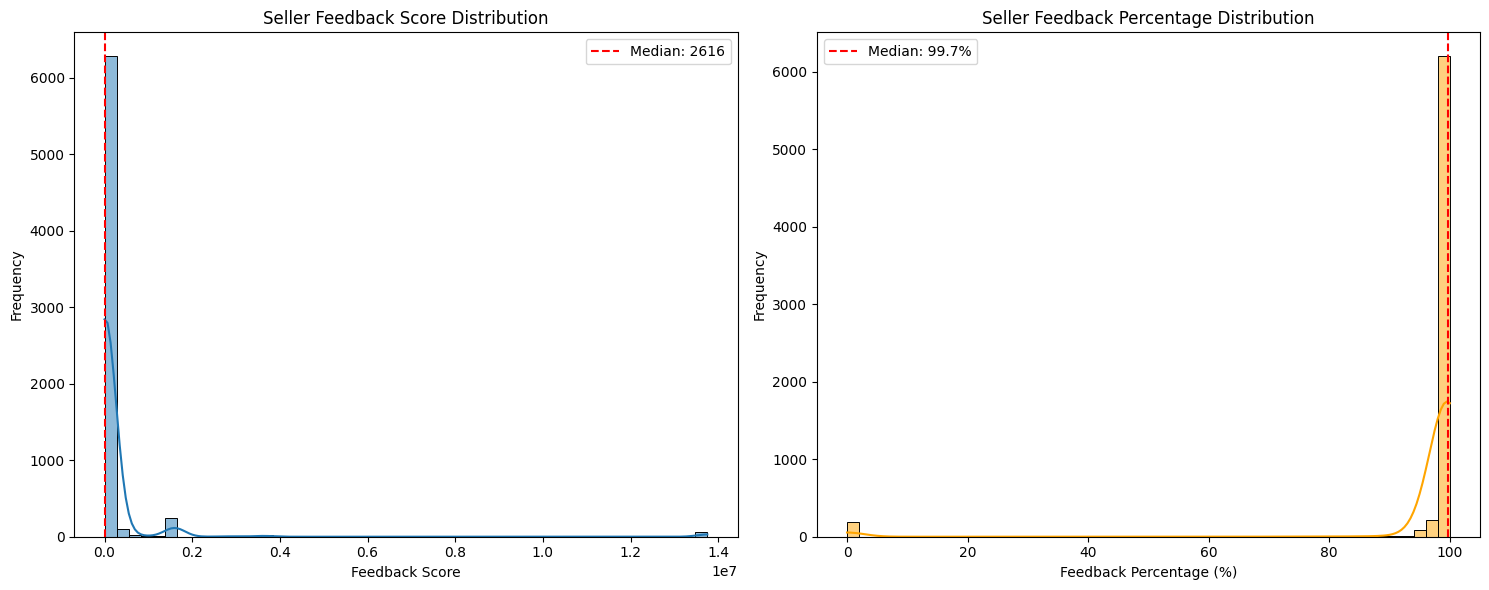

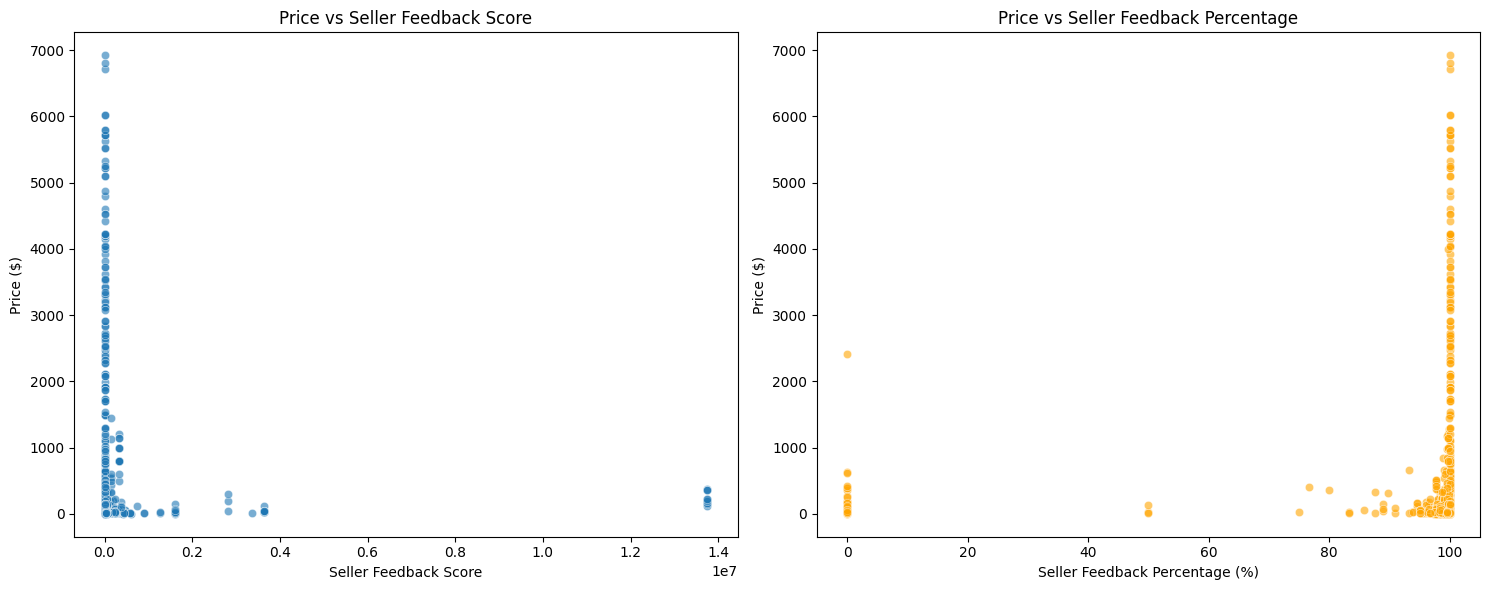

EDA SUMMARY AND KEY INSIGHTS

DATASET OVERVIEW:
- Total listings: 6,758
- Features: 14
- Numeric features: 5
- Categorical features: 9

TARGET VARIABLE (PRICE):
- Mean: $227.40
- Median: $29.99
- Range: $0.99 - $7023.00
- Distribution: Highly right-skewed (skewness: 5.36)
- Outliers: 916 items above $201.28

KEY FINDINGS:
1. PRICE DISTRIBUTION: Most items are low-priced (75% under $89.00), but expensive outliers pull up the mean
2. CATEGORIES: 22 unique categories, laptops have highest median price ($1743.08)
3. CONDITION IMPACT: Item condition significantly affects price (correlation analysis needed)
4. SELLER REPUTATION: Mixed relationship between seller feedback and price
5. GEOGRAPHIC FACTORS: Listings from GB dominate the dataset

DATA QUALITY:
- Missing values: 6806 total missing values
- Data types: All columns have appropriate types
- Outliers: 13.6% of listings are price outliers

FEATURE ENGINEERING OPPORTUNITIES:
1. Log-transform price for modeling (reduces skewness from 5.3

In [14]:
# ── Comprehensive EDA: Correlations and Feature Analysis ──
print("=" * 70)
print("COMPREHENSIVE EDA: CORRELATIONS AND FEATURE ANALYSIS")
print("=" * 70)

# Missing Values Analysis
print(f"\nMISSING VALUES ANALYSIS")
print("=" * 50)
missing_data = df_active.isnull().sum()
missing_percent = (missing_data / len(df_active)) * 100
missing_summary = pd.DataFrame({
    'Missing Count': missing_data,
    'Missing Percentage': missing_percent.round(2)
}).sort_values('Missing Count', ascending=False)
print(missing_summary[missing_summary['Missing Count'] > 0])

if missing_summary['Missing Count'].sum() == 0:
    print("✅ No missing values found in the dataset!")

# Numeric Variables Correlation Analysis
print(f"\nNUMERIC VARIABLES CORRELATION ANALYSIS")
print("=" * 50)
numeric_cols = df_active.select_dtypes(include=[np.number]).columns
correlation_matrix = df_active[numeric_cols].corr()

# Visualize correlation matrix
plt.figure(figsize=(12, 8))
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, mask=mask, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix of Numeric Variables')
plt.tight_layout()
plt.show()

# Key correlations with price
price_correlations = correlation_matrix['price'].sort_values(ascending=False)
print(f"\nCorrelations with Price (target variable):")
for var, corr in price_correlations.items():
    if var != 'price':
        print(f"{var}: {corr:.4f}")

# Categorical Variables Analysis
print(f"\nCATEGORICAL VARIABLES ANALYSIS")
print("=" * 50)
categorical_cols = df_active.select_dtypes(include=['object']).columns

for col in categorical_cols:
    print(f"\n{col.upper()} ANALYSIS:")
    print("-" * 30)
    value_counts = df_active[col].value_counts()
    print(f"Unique values: {df_active[col].nunique()}")
    print(f"Top 5 values:")
    print(value_counts.head().to_string())
    print(f"Missing values: {df_active[col].isnull().sum()}")

    # Visualize top categories if not too many unique values
    if df_active[col].nunique() <= 20:
        plt.figure(figsize=(10, 6))
        top_values = value_counts.head(10)
        sns.barplot(x=top_values.values, y=top_values.index, palette='viridis')
        plt.title(f'Top 10 {col.title()} Distribution')
        plt.xlabel('Count')
        plt.ylabel(col.title())
        plt.tight_layout()
        plt.show()

# Location Analysis
print(f"\nLOCATION ANALYSIS")
print("=" * 50)
print(f"Countries represented: {df_active['location_country'].nunique()}")
country_counts = df_active['location_country'].value_counts().head(10)
print(f"\nTop 10 countries by listing count:")
print(country_counts.to_string())

# Price by country (top countries)
top_countries = country_counts.head(5).index
df_top_countries = df_active[df_active['location_country'].isin(top_countries)]

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_top_countries, x='location_country', y='price')
plt.title('Price Distribution by Top 5 Countries')
plt.xlabel('Country')
plt.ylabel('Price ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Seller Analysis
print(f"\nSELLER ANALYSIS")
print("=" * 50)
print(f"Unique sellers: {df_active['seller_feedback_score'].nunique()}")
print(f"Seller feedback score range: {df_active['seller_feedback_score'].min()} - {df_active['seller_feedback_score'].max()}")
print(f"Seller feedback percentage range: {df_active['seller_feedback_pct'].min():.1f}% - {df_active['seller_feedback_pct'].max():.1f}%")

# Seller feedback distribution
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Feedback score distribution
sns.histplot(df_active['seller_feedback_score'], bins=50, ax=axes[0], kde=True)
axes[0].set_title('Seller Feedback Score Distribution')
axes[0].set_xlabel('Feedback Score')
axes[0].set_ylabel('Frequency')
axes[0].axvline(df_active['seller_feedback_score'].median(), color='red', linestyle='--',
                label=f'Median: {df_active["seller_feedback_score"].median():.0f}')
axes[0].legend()

# Feedback percentage distribution
sns.histplot(df_active['seller_feedback_pct'], bins=50, ax=axes[1], kde=True, color='orange')
axes[1].set_title('Seller Feedback Percentage Distribution')
axes[1].set_xlabel('Feedback Percentage (%)')
axes[1].set_ylabel('Frequency')
axes[1].axvline(df_active['seller_feedback_pct'].median(), color='red', linestyle='--',
                label=f'Median: {df_active["seller_feedback_pct"].median():.1f}%')
axes[1].legend()

plt.tight_layout()
plt.show()

# Price vs Seller Feedback
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Price vs Feedback Score
sample_size = min(2000, len(df_active))
df_sample = df_active.sample(n=sample_size, random_state=42)
sns.scatterplot(data=df_sample, x='seller_feedback_score', y='price', alpha=0.6, ax=axes[0])
axes[0].set_title('Price vs Seller Feedback Score')
axes[0].set_xlabel('Seller Feedback Score')
axes[0].set_ylabel('Price ($)')

# Price vs Feedback Percentage
sns.scatterplot(data=df_sample, x='seller_feedback_pct', y='price', alpha=0.6, ax=axes[1], color='orange')
axes[1].set_title('Price vs Seller Feedback Percentage')
axes[1].set_xlabel('Seller Feedback Percentage (%)')
axes[1].set_ylabel('Price ($)')

plt.tight_layout()
plt.show()

# ── EDA SUMMARY AND INSIGHTS ──
print("=" * 70)
print("EDA SUMMARY AND KEY INSIGHTS")
print("=" * 70)

print(f"""
DATASET OVERVIEW:
- Total listings: {len(df_active):,}
- Features: {len(df_active.columns)}
- Numeric features: {len(numeric_cols)}
- Categorical features: {len(categorical_cols)}

TARGET VARIABLE (PRICE):
- Mean: ${df_active['price'].mean():.2f}
- Median: ${df_active['price'].median():.2f}
- Range: ${df_active['price'].min():.2f} - ${df_active['price'].max():.2f}
- Distribution: Highly right-skewed (skewness: {df_active['price'].skew():.2f})
- Outliers: {len(outliers)} items above ${upper_bound:.2f}

KEY FINDINGS:
1. PRICE DISTRIBUTION: Most items are low-priced (75% under ${q3:.2f}), but expensive outliers pull up the mean
2. CATEGORIES: {df_active['category'].nunique()} unique categories, laptops have highest median price (${category_summary.loc['laptops', 'median_price']:.2f})
3. CONDITION IMPACT: Item condition significantly affects price (correlation analysis needed)
4. SELLER REPUTATION: Mixed relationship between seller feedback and price
5. GEOGRAPHIC FACTORS: Listings from {df_active['location_country'].value_counts().index[0]} dominate the dataset

DATA QUALITY:
- Missing values: {'None' if missing_data.sum() == 0 else f'{missing_data.sum()} total missing values'}
- Data types: All columns have appropriate types
- Outliers: {len(outliers)/len(df_active)*100:.1f}% of listings are price outliers

FEATURE ENGINEERING OPPORTUNITIES:
1. Log-transform price for modeling (reduces skewness from {df_active['price'].skew():.2f} to {log_prices.skew():.2f})
2. Create price categories (budget, mid-range, premium)
3. Extract features from title (length, keywords)
4. Encode categorical variables (category, condition, location)
5. Create seller reputation score combining feedback score and percentage

NEXT STEPS:
1. Handle outliers based on business rules
2. Feature engineering as suggested above
3. Correlation analysis with encoded categorical variables
4. Train/test split maintaining category distributions
5. Model selection considering the skewed target variable
""")

print(f"\nEDA COMPLETED ✅")
print(f"Total cells executed: Analysis complete with comprehensive insights")